In [1]:
import pandas as pd 
import seaborn as sns

In [3]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
titanic = pd.read_csv('Titanic-Dataset.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


### 1. Scatterplot ( Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

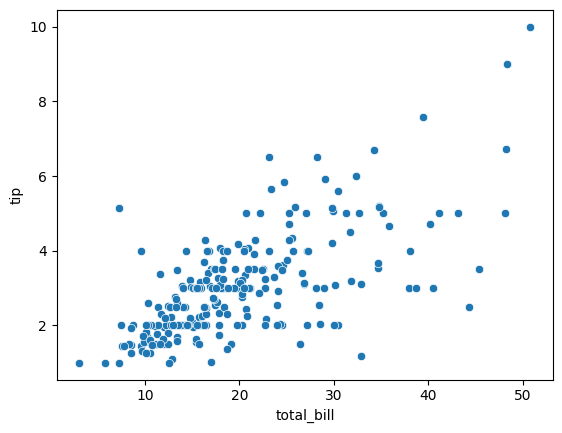

In [10]:
sns.scatterplot(x = tips['total_bill'], y = tips['tip'])
# hue: Grouping variable that will produce points with different colors. Can be either categorical or numeric, 

##### Conducting the multivariate analysis in the same data columns

<Axes: xlabel='total_bill', ylabel='tip'>

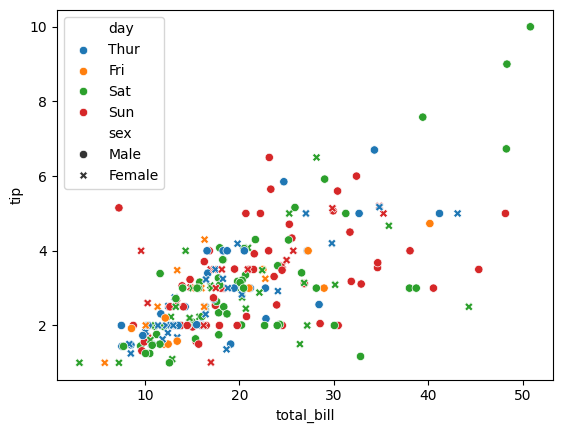

In [13]:
sns.scatterplot(x = tips['total_bill'], y = tips['tip'], hue = tips['day'],style = tips['sex'] )
 # value of x and y gives the bivariate analysis and the other arguments help in multivariate analysis.

### 2. Bar Plot (Numerical data - Categorical data)

<Axes: xlabel='Pclass', ylabel='Age'>

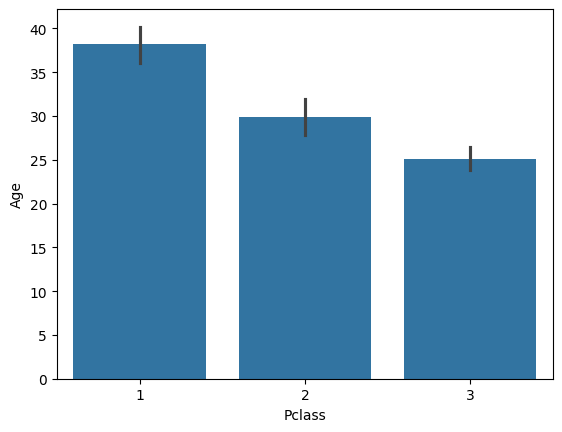

In [14]:
sns.barplot(x = titanic['Pclass'], y = titanic['Age'])

<Axes: xlabel='Pclass', ylabel='Fare'>

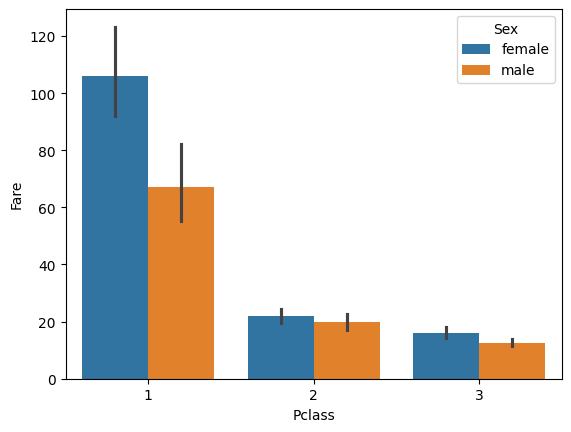

In [6]:
sns.barplot(x = titanic['Pclass'], y = titanic['Fare'], hue = titanic['Sex'])


### 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

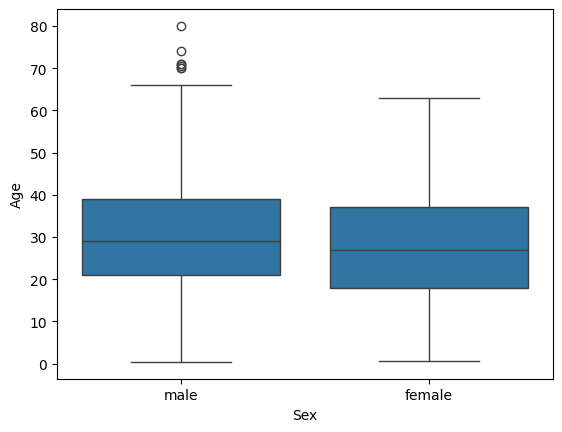

In [10]:
sns.boxplot(x = titanic['Sex'], y = titanic['Age'])

<Axes: xlabel='Pclass', ylabel='Age'>

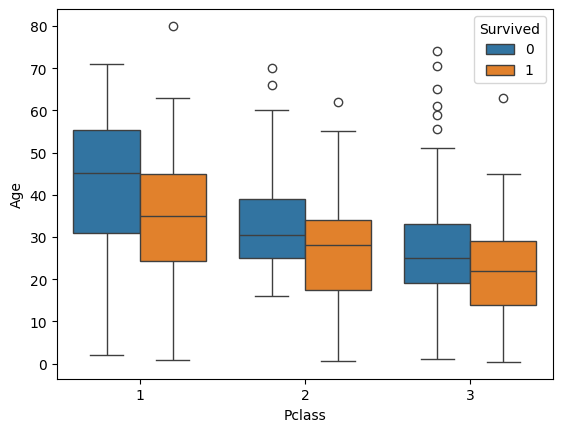

In [11]:
sns.boxplot(x = titanic['Pclass'], y = titanic['Age'], hue = titanic['Survived'])

### 4. Displot ( Numerical - categorical)

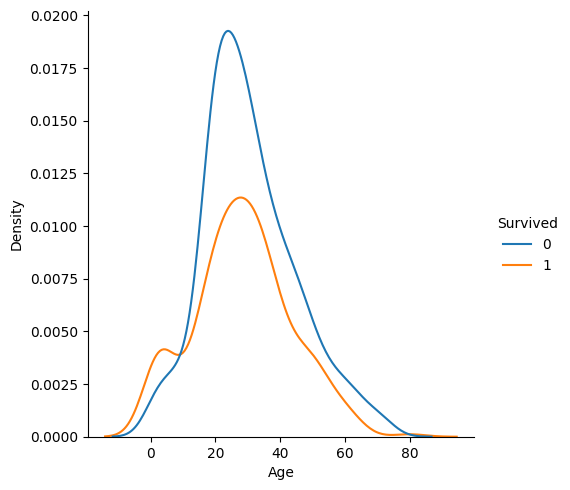

In [18]:
sns.displot(x = titanic['Age'], hue = titanic['Survived'], kind = 'kde')

### 6. Heatmap (Categorical vs Categorical)

In [19]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
pd.crosstab(titanic['Pclass'], columns = titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

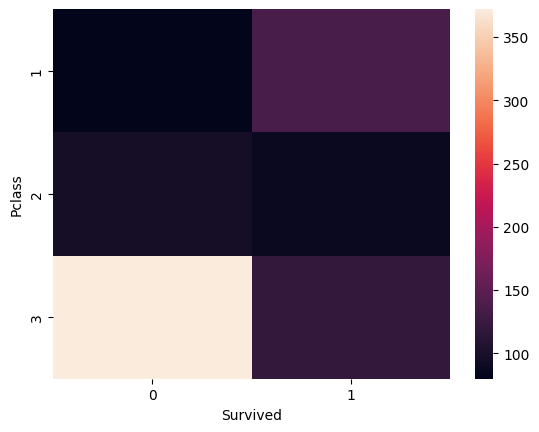

In [23]:
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Survived']))

In [6]:
titanic.groupby('Pclass')['Survived'].mean() * 100 # Percentage of people of each class who survived.

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: xlabel='Pclass'>

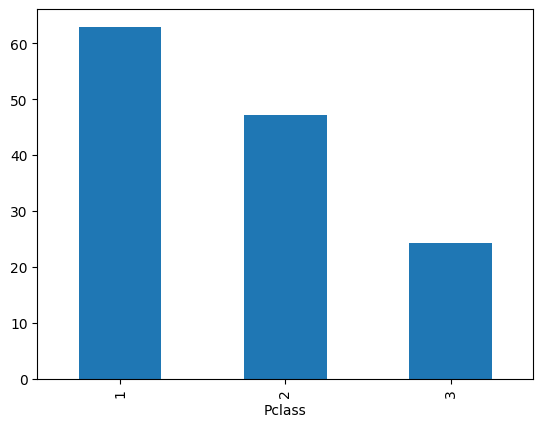

In [7]:
# We can plot the above information

(titanic.groupby('Pclass')['Survived'].mean() *100).plot(kind = 'bar')

### 7. Cluster map (categorical - categorical)

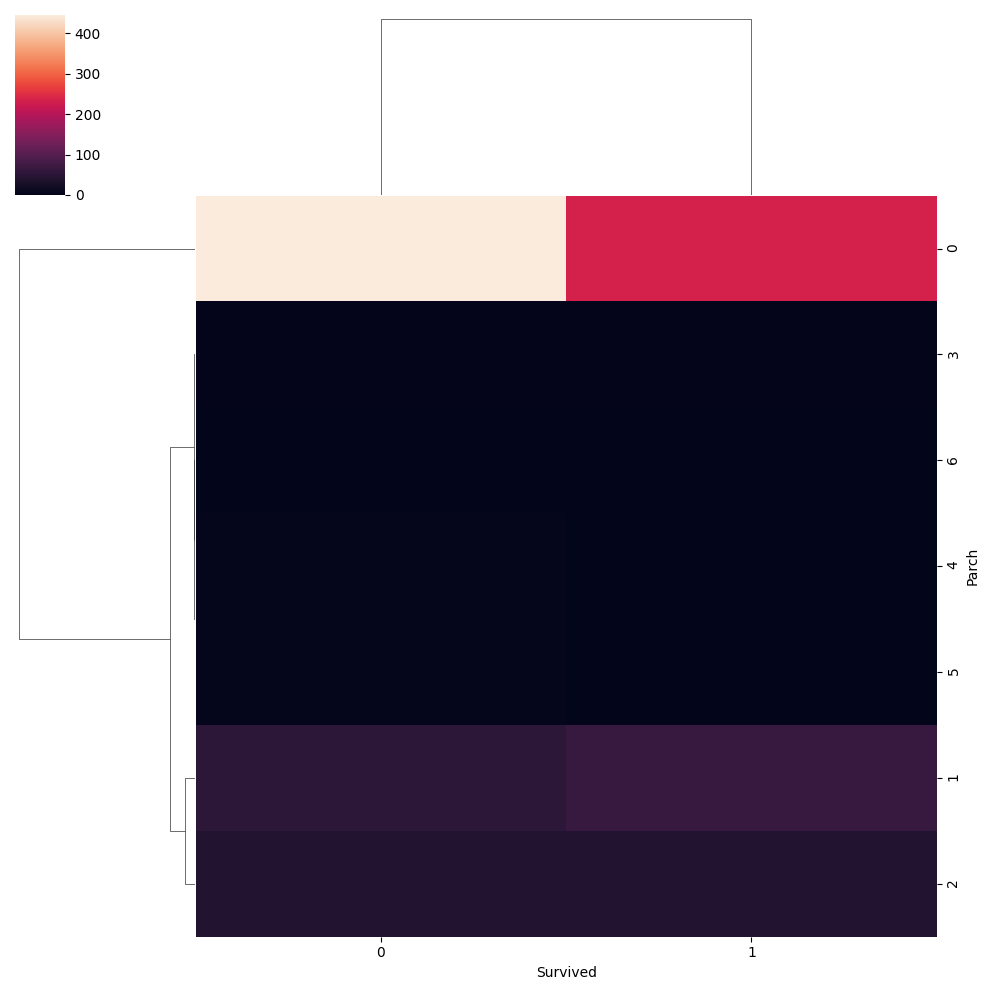

In [10]:
sns.clustermap(pd.crosstab(titanic['Parch'], titanic['Survived']))

 ### 8. Pairplot

In [12]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


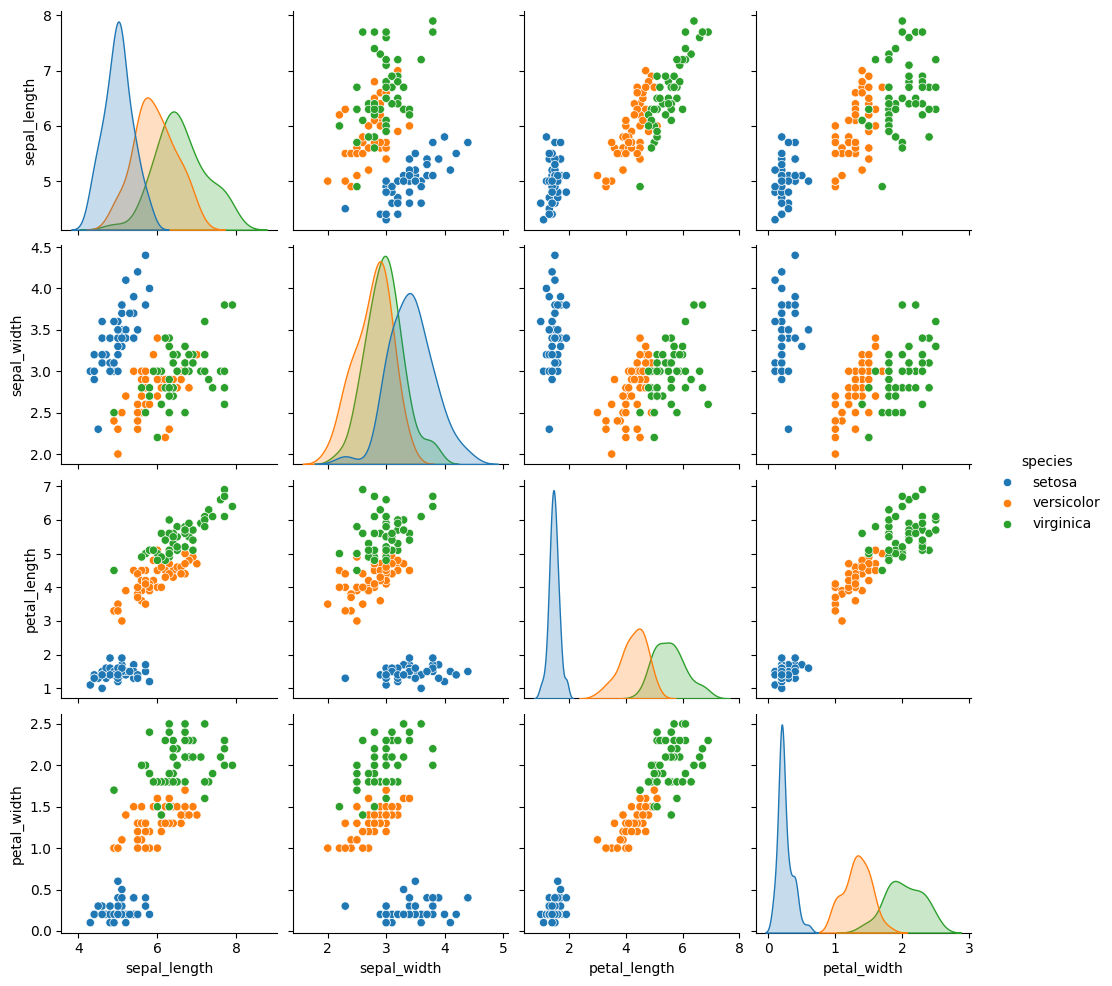

In [17]:
sns.pairplot(iris, hue = 'species')

### 9. Line plot ( Numerical - Numerical)

In [18]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<Axes: xlabel='year', ylabel='passengers'>

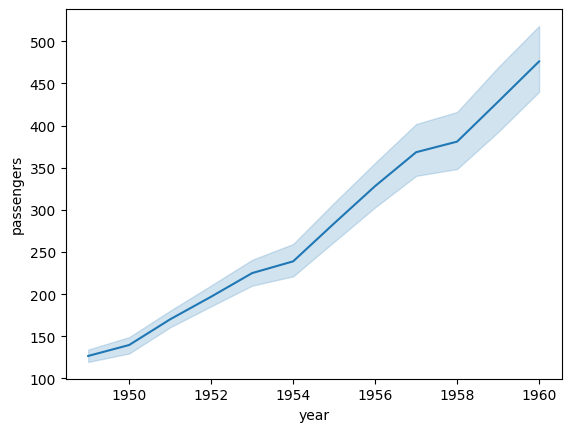

In [22]:
sns.lineplot(x = flights['year'],y = flights['passengers'])

In [34]:
new_df = flights.groupby('year')['passengers'].sum().reset_index()
new_df

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

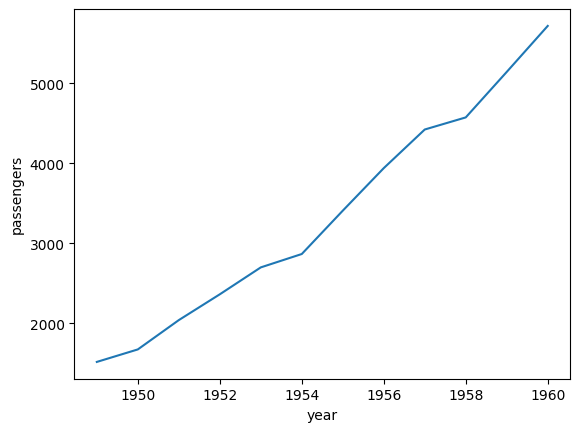

In [36]:
sns.lineplot(x = new_df['year'], y = new_df['passengers'])

In [38]:
flights.pivot_table(values = 'passengers', index = 'month', columns = 'year')

C:\Users\T U F\AppData\Local\Temp\ipykernel_18804\2751891872.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values = 'passengers', index = 'month', columns = 'year')


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


C:\Users\T U F\AppData\Local\Temp\ipykernel_18804\1986178198.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flights.pivot_table(values = 'passengers', index = 'month', columns = 'year'),cmap = 'coolwarm')


<Axes: xlabel='year', ylabel='month'>

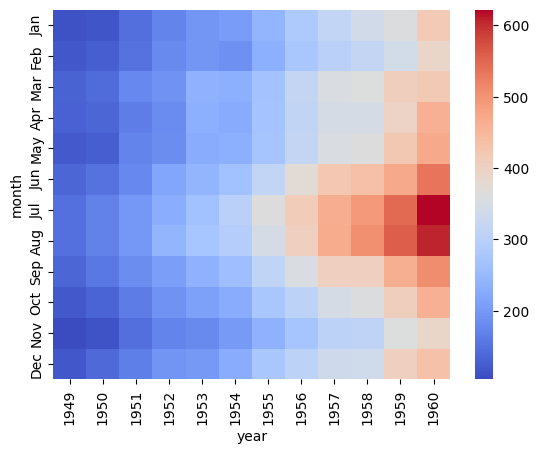

In [42]:
#flights.pivot_table(values = 'passengers', index = 'month', columns = 'year')
sns.heatmap(flights.pivot_table(values = 'passengers', index = 'month', columns = 'year'),cmap = 'coolwarm')

C:\Users\T U F\AppData\Local\Temp\ipykernel_18804\797578557.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flights.pivot_table(values = 'passengers', index = 'month', columns = 'year'),cmap = 'coolwarm')


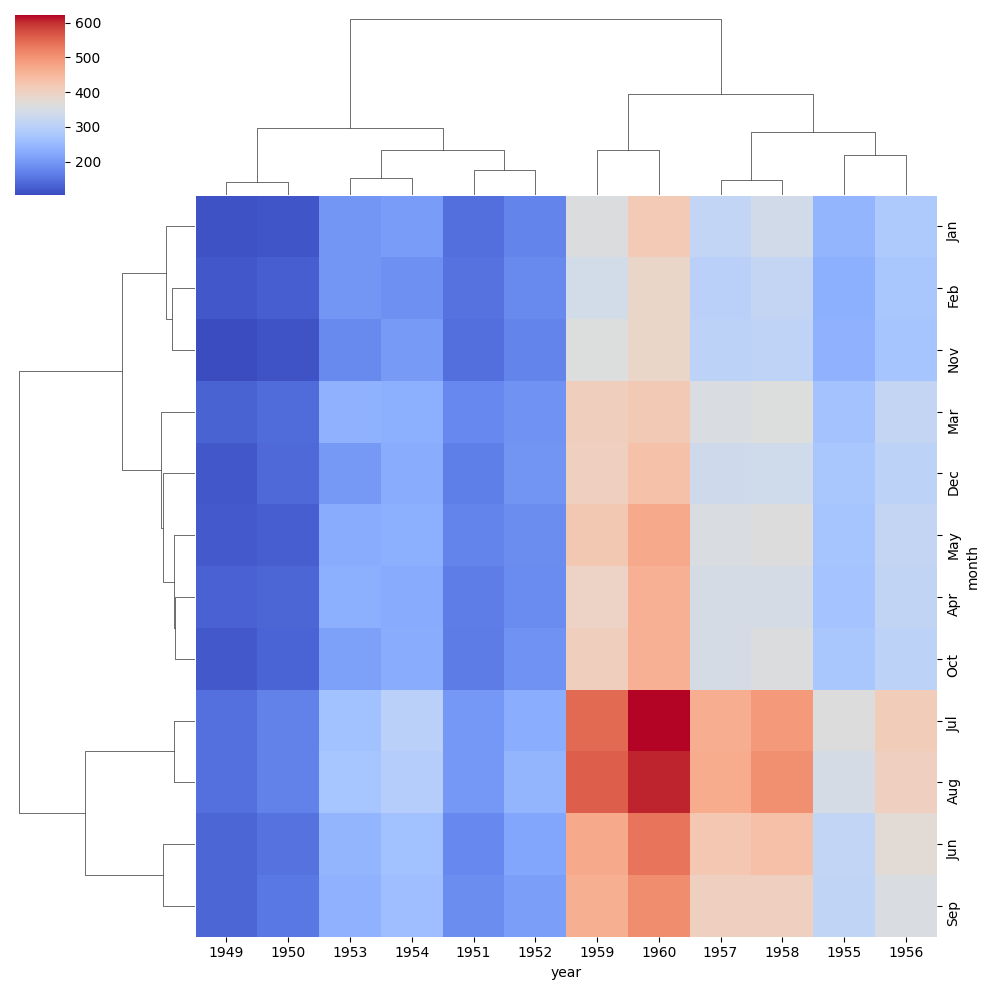

In [43]:
sns.clustermap(flights.pivot_table(values = 'passengers', index = 'month', columns = 'year'),cmap = 'coolwarm')